## Time Series Forecasting Fundamentals with TensorFlow

#### Let's predict the price of Bitcoin based on the historical price of Bitcoin.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import datetime as dt
import os
import tensorflow as tf
warnings.filterwarnings("ignore")
print(tf.__version__)

2.18.0


## Get the data...

In [ ]:
# !mkdir ~/.kaggle
# !cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download mczielinski/bitcoin-historical-data
!unzip bitcoin-historical-data

Dataset URL: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data
License(s): CC-BY-SA-4.0
 86% 78.0M/90.2M [00:00<00:00, 139MB/s]
100% 90.2M/90.2M [00:00<00:00, 100MB/s]
Archive:  bitcoin-historical-data.zip
  inflating: btcusd_1-min_data.csv   


In [ ]:
df = pd.read_csv("/content/btcusd_1-min_data.csv")
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6779281 entries, 0 to 6779280
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 310.3 MB


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df['Date'] = df['Timestamp'].dt.date
df['Time'] = df['Timestamp'].dt.time
df.head()

,Timestamp,Open,High,Low,Close,Volume,Date,Time
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:01:00
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:02:00
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:03:00
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:04:00
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:05:00


In [ ]:
df = df.drop(['Timestamp'], axis=1)
df.head()

,Open,High,Low,Close,Volume,Date,Time
0,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:01:00
1,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:02:00
2,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:03:00
3,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:04:00
4,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:05:00


In [ ]:
df = df.groupby('Date')['Close'].mean().reset_index()
df.head()

,Date,Close
0,2012-01-01,4.645697
1,2012-01-02,4.975000
2,2012-01-03,5.085500
3,2012-01-04,5.170396
4,2012-01-05,5.954361


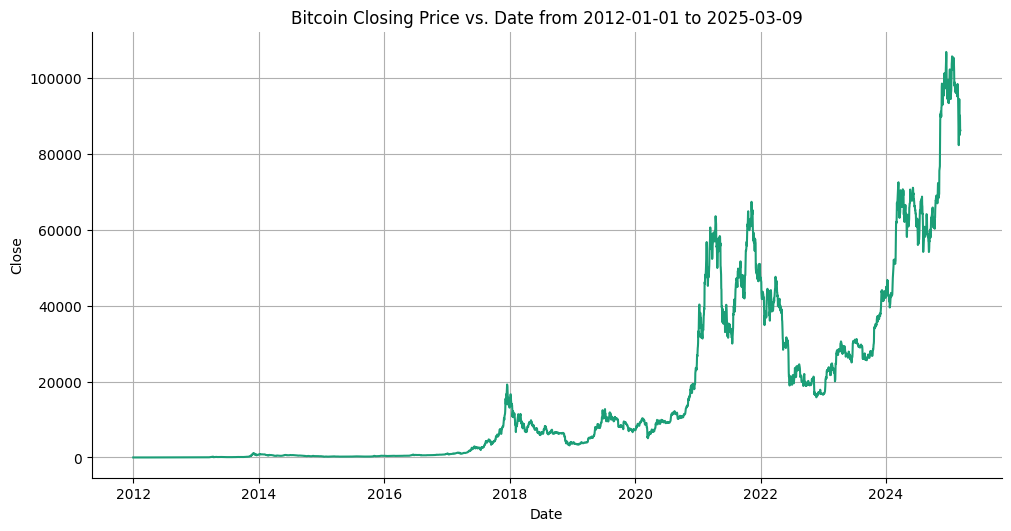

In [ ]:
# @title Date vs Close

def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Close']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])
  plt.title(f"Bitcoin Closing Price vs. Date from {xs.min()} to {xs.max()}")
  plt.grid(True)
  return plt

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Close')

#### Convert dataset columns to Numpy arrays.

In [ ]:
timesteps = df['Date'].to_numpy()
prices = df['Close'].to_numpy()
timesteps,prices

(array([datetime.date(2012, 1, 1), datetime.date(2012, 1, 2),
        datetime.date(2012, 1, 3), ..., datetime.date(2025, 3, 7),
        datetime.date(2025, 3, 8), datetime.date(2025, 3, 9)], dtype=object),
 array([4.64569726e+00, 4.97500000e+00, 5.08550000e+00, ...,
        8.98730000e+04, 8.61657968e+04, 8.61820000e+04]))

#### Create train and test splits

In [26]:
split_size = int(np.size(timesteps) * 0.8)
X_train, X_test = timesteps[:split_size], timesteps[split_size:]
y_train, y_test = prices[:split_size], prices[split_size:]

#### Plot train and test datasets.

In [33]:
# Create a function to plot time series data
def plot_time_series(timesteps, values, format='.', start=0, end=None, label=None):
  """
  Plots a timesteps (a series of points in time) against values (a series of values across timesteps).

  Parameters
  ---------
  timesteps : array of timesteps
  values : array of values across time
  format : style of plot, default "."
  start : where to start the plot (setting a value will index from start of timesteps & values)
  end : where to end the plot (setting a value will index from end of timesteps & values)
  label : label to show on plot of values
  """
  # Plot the series
  plt.plot(timesteps[start:end], values[start:end], format, label=label)
  plt.xlabel("Time")
  plt.ylabel("BTC Price")
  if label:
    plt.legend(fontsize=14) # make label bigger
  plt.grid(True)


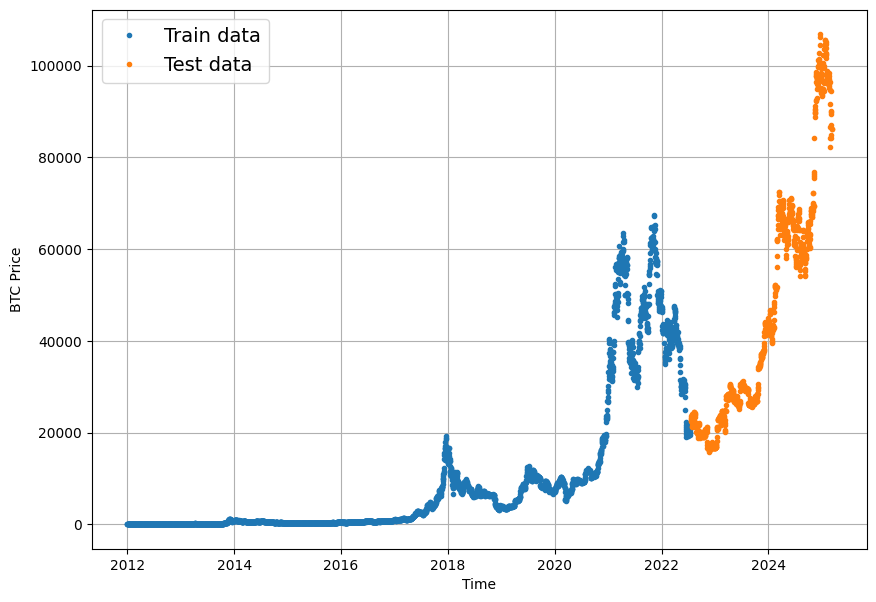

In [34]:
# Try out our plotting function
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")

## Let's Build A Few Models.

Model Number | Model Type  | Horizon size | Window size | Extra data |
-------------|-------------|--------------|-------------|------------|
0 | Naive model (baseline) |    NA        |     NA      |  NA        |      
1 | Dense model            | 1 | 7 | NA |
2	|Same as 1	|1	|30	|NA|
3	|Same as 1|	7	|30	|NA|
4	|Conv1D	|1	|7	|NA|
5	|LSTM	|1	|7	|NA|
6	|Same as 1 (but with multivariate data)|	1|	7|	Block reward size
7	|N-BEATs Algorithm|	1	|7	|NA |
8	|Ensemble (multiple models optimized on different loss functions)|	1	|7	|NA
9	|Future prediction model (model to predict future values)|	1|	7	|NA|
10|	Same as 1 (but with turkey 🦃 data introduced)|	1	|7	|NA|


#### Model 0: Naive Forecast where   $\hat{y_t} = y_{t-1}$

In [35]:
# Create a naïve forecast
naive_forecast = y_test[:-1] # Naïve forecast equals every value excluding the last value
naive_forecast[:10], naive_forecast[-10:] # View first 10 and last 10

(array([23583.01938194, 22976.18275   , 23219.21743056, 22571.84520139,
        22590.34086806, 22096.39465278, 21178.70126389, 21368.88505556,
        23129.02411111, 23893.62595833]),
 array([84223.        , 82306.46846847, 84288.        , 89412.8008008 ,
        94422.        , 84901.57157157, 87172.        , 90110.16716717,
        89873.        , 86165.7967968 ]))

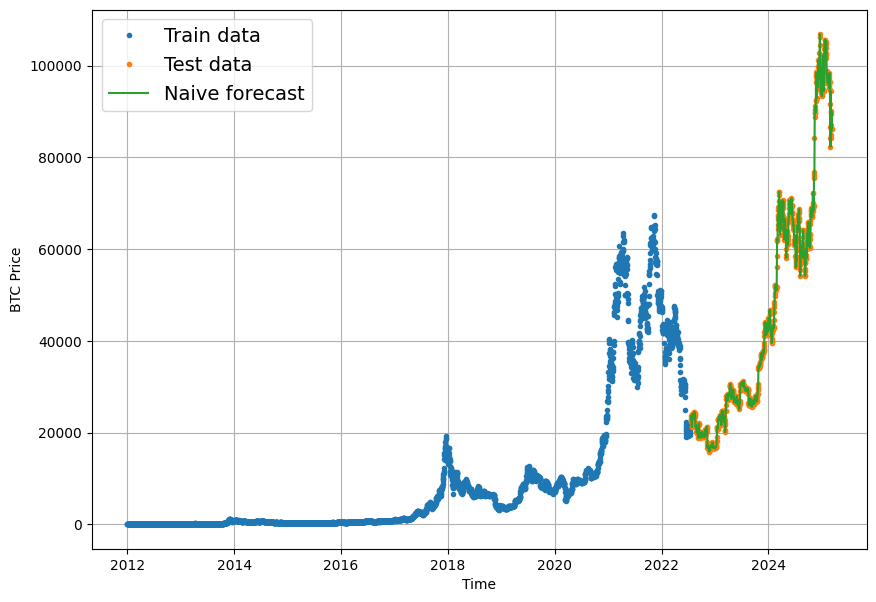

In [36]:
# Plot naive forecast
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-", label="Naive forecast");

#### Let's zoom in on the above plot...

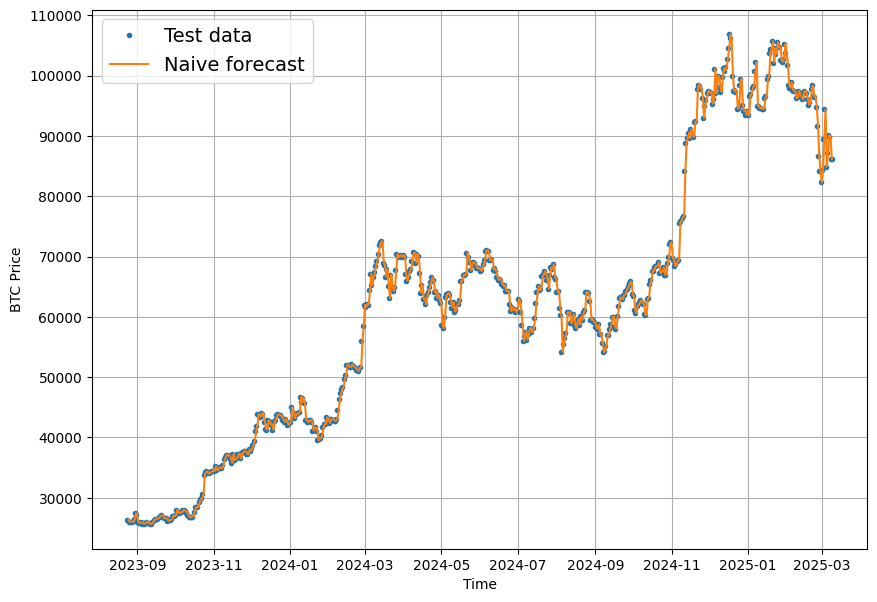

In [41]:
plt.figure(figsize=(10, 7))
offset = 400 # offset the values by 400 timesteps
plot_time_series(timesteps=X_test, values=y_test, start=offset, label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-", start=offset, label="Naive forecast");


#### Scale-dependent errors

These are metrics which can be used to compare time series values and forecasts that are on the same scale.

For example, Bitcoin historical prices in USD versus Bitcoin forecast values in USD.

We can use

* `tf.keras.metrics.mean_absolute_error()`
* `tf.sqrt(tf.keras.metrics.mean_squared_error())`

In [51]:
# MASE implemented courtesy of sktime - https://github.com/alan-turing-institute/sktime/blob/ee7a06843a44f4aaec7582d847e36073a9ab0566/sktime/performance_metrics/forecasting/_functions.py#L16
def mean_absolute_scaled_error(y_true, y_pred):
  """
  Implement MASE (assuming no seasonality of data).
  """
  mae = tf.reduce_mean(tf.abs(y_true - y_pred))

  # Find MAE of naive forecast (no seasonality)
  mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1])) # our seasonality is 1 day (hence the shifting of 1 day)

  return mae / mae_naive_no_season

#### Set up instances of `mae`, `mse` and `mape`.

In [ ]:
mae = tf.keras.losses.MeanAbsoluteError()
mse = tf.keras.losses.MeanSquaredError()
mape = tf.keras.losses.MeanAbsolutePercentageError()

In [62]:
def evaluate_preds(y_true, y_pred):
  # Make sure float32 (for metric calculations)
  y_true = tf.cast(y_true, dtype=tf.float32)
  y_pred = tf.cast(y_pred, dtype=tf.float32)

  # Calculate various metrics
  mae_result = mae(y_true, y_pred)
  mse_result = mse(y_true, y_pred) # puts and emphasis on outliers (all errors get squared)
  rmse = tf.sqrt(mse_result)
  mape_result = mape(y_true, y_pred)

  return {"mae": mae_result.numpy(),
          "mse": mse_result.numpy(),
          "rmse": rmse.numpy(),
          "mape": mape_result.numpy()}

In [63]:
naive_results = evaluate_preds(y_true=y_test[1:],
                               y_pred=naive_forecast)
naive_results

{'mae': 714.5324, 'mse': 1495466.2, 'rmse': 1222.8926, 'mape': 1.4831345}

In [64]:
# Find average price of Bitcoin in test dataset
tf.reduce_mean(y_test).numpy()

46091.59614152628

Okay, looking at these two values is starting to give us an idea of how our model is performing:

The average price of Bitcoin in the test dataset is: $46,091 (note: average may not be the best measure here, since the highest price is over 3x this value and the lowest price is over 4x lower)

Each prediction in naive forecast is on average off by: $714.

Can we do better than this??

#### Windowing

Windowing is a method to turn a time series dataset into supervised learning problem.

In other words, we want to use windows of the past to predict the future.

For example for a univariate time series, windowing for one week (window=7) to predict the next single value (horizon=1) might look like:

```
Window for one week (univariate time series)

[0, 1, 2, 3, 4, 5, 6] -> [7]

[1, 2, 3, 4, 5, 6, 7] -> [8]

[2, 3, 4, 5, 6, 7, 8] -> [9]

```

In [65]:
HORIZON = 1 # predict 1 step at a time
WINDOW_SIZE = 7 # use a week worth of timesteps to predict the horizon

In [66]:
# Create function to label windowed data
def get_labelled_windows(x, horizon=1):
  """
  Creates labels for windowed dataset.

  E.g. if horizon=1 (default)
  Input: [1, 2, 3, 4, 5, 6] -> Output: ([1, 2, 3, 4, 5], [6])
  """
  return x[:, :-horizon], x[:, -horizon:]

In [80]:
x = tf.expand_dims(np.array([1, 2, 3, 4, 5, 6]),axis=0)
x[:,:-1]

<tf.Tensor: shape=(1, 5), dtype=int64, numpy=array([[1, 2, 3, 4, 5]])>

In [82]:
x[:,-1:]

<tf.Tensor: shape=(1, 1), dtype=int64, numpy=array([[6]])>

In [84]:
get_labelled_windows(x, horizon=1)

(<tf.Tensor: shape=(1, 5), dtype=int64, numpy=array([[1, 2, 3, 4, 5]])>,
 <tf.Tensor: shape=(1, 1), dtype=int64, numpy=array([[6]])>)

In [ ]:

# Create function to view NumPy arrays as windows
def make_windows(x, window_size=7, horizon=1):
  """
  Turns a 1D array into a 2D array of sequential windows of window_size.
  """
  # 1. Create a window of specific window_size (add the horizon on the end for later labelling)
  window_step = np.expand_dims(np.arange(window_size+horizon), axis=0)
  # print(f"Window step:\n {window_step}")

  # 2. Create a 2D array of multiple window steps (minus 1 to account for 0 indexing)
  window_indexes = window_step + np.expand_dims(np.arange(len(x)-(window_size+horizon-1)), axis=0).T # create 2D array of windows of size window_size
  # print(f"Window indexes:\n {window_indexes[:3], window_indexes[-3:], window_indexes.shape}")

  # 3. Index on the target array (time series) with 2D array of multiple window steps
  windowed_array = x[window_indexes]

  # 4. Get the labelled windows
  windows, labels = get_labelled_windows(windowed_array, horizon=horizon)

  return windows, labels